# Structure-free invariant autoencoders: four experiments × three training regimes

This notebook continues `phase_separation_fully_equivariant_graph_autoencoder.ipynb` but removes every Steinhardt/CNA/PTM target. It asks whether a **single global latent vector** can describe an unordered 18-neighbor environment and reconstruct its geometry without knowing its input orientation.

The contract is

$$z(PXR^\top)=z(X),\qquad \hat X(PXR^\top)=\hat X(X),$$

where $P$ permutes neighbors and $R\in SO(3)$. Intermediate particle features are necessarily permutation equivariant; after global pooling the latent and canonical decoded set are invariant. Decoder output slots have no particle identity, and all reconstruction losses treat them as an unordered set.

Four study blocks are implemented:

1. **Invariant distance GNN + fused Gromov–Wasserstein (FGW)**.
2. **Loss study on the same GNN:** sorted distances, Sinkhorn–Kabsch, and anchor-frame Chamfer versus FGW.
3. **Invariant distance-aware Set Transformer + FGW**.
4. **Continuous steerable point convolution + invariant pooling + FGW**.

Every model/loss combination runs in three regimes: clean autoencoding, Gaussian denoising, and masked-neighbor reconstruction. Phase labels are evaluation-only.


## Experimental map

| study | encoder | latent | decoder | reconstruction loss |
|---|---|---|---|---|
| E1 | distance message passing | global scalar vector | canonical unordered point set | fused GW |
| E2 | same distance GNN | same | same | sorted distances / Sinkhorn–Kabsch / anchor frame |
| E3 | distance-biased self-attention | global scalar vector | same | fused GW |
| E4 | spherical-harmonic continuous filters | pooled irrep norms → global scalar vector | same | fused GW |

Spherical harmonics in E4 are only a rotation-group basis used inside learned filters. No $q_l$, $w_l$, structure label, or descriptor is loaded or predicted.

The anchor loss is the computationally tractable version of the proposed center-plus-three-neighbor alignment. It constructs a frame from three geometrically selected anchors. Its expected weakness—discontinuous anchor changes near symmetric/tied configurations—is part of the comparison.


In [1]:
# Imports
import gc
import os
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# e3nn 0.4.x bundles trusted local Wigner constants containing Python slices.
# PyTorch >=2.6 requires explicitly allow-listing that harmless built-in type.
try:
    torch.serialization.add_safe_globals([slice])
except AttributeError:
    pass

try:
    import e3nn
    from e3nn import o3
    from e3nn.nn import NormActivation
    E3NN_AVAILABLE = True
    warnings.filterwarnings(
        "ignore",
        message="The TorchScript type system doesn't support instance-level annotations.*",
        category=UserWarning,
    )
except Exception as error:
    E3NN_AVAILABLE = False
    E3NN_IMPORT_ERROR = repr(error)


In [2]:
# Shared configuration
PHASES = ("liquid", "fcc", "hcp")
LABEL_MAP = {phase: i for i, phase in enumerate(PHASES)}
LABEL_COLORS = {"liquid": "tab:green", "fcc": "tab:blue", "hcp": "tab:orange"}
DATA_FILENAME = "particle_data_second_shell.npz"
N_NEIGHBORS = 18
N_NODES = N_NEIGHBORS + 1

MAIN_SEED = 42
ROBUSTNESS_SEEDS = (42, 43, 44, 45, 46)
MAX_SAMPLES_PER_PHASE = 1_200
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20

LATENT_DIMENSIONS = (16, 32, 64)  # use 32 in the main matrix; ablation hook below
LATENT_DIM = 32
HIDDEN_DIM = 48
N_ENCODER_LAYERS = 3
RBF_DIM = 12
BATCH_SIZE = 96
MAX_EPOCHS = 22
PATIENCE = 5
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 5.0

DENOISE_SIGMA = 0.05          # relative to median training neighbor radius
MASK_FRACTION = 0.25
REGIMES = ("clean", "denoise", "masked")

FGW_OUTER_STEPS = 4
SINKHORN_STEPS = 12
SINKHORN_TEMPERATURE = 0.08
FGW_RADIAL_WEIGHT = 0.5

EVAL_MAX_SAMPLES = 500
NOISE_LEVELS = (0.01, 0.03, 0.05, 0.10)
RUN_MAIN_BENCHMARK = True
RUN_FIVE_SEED_ROBUSTNESS = False  # 90 fits: deliberately opt-in
RUN_LATENT_WIDTH_ABLATION = False

if os.environ.get("AE_SMOKE_TEST") == "1":
    MAX_SAMPLES_PER_PHASE = 12
    BATCH_SIZE = 12
    MAX_EPOCHS = 1
    PATIENCE = 1
    HIDDEN_DIM = 16
    N_ENCODER_LAYERS = 1
    FGW_OUTER_STEPS = 2
    SINKHORN_STEPS = 4
    EVAL_MAX_SAMPLES = 24

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("e3nn available:", E3NN_AVAILABLE, getattr(e3nn, "__version__", None) if E3NN_AVAILABLE else E3NN_IMPORT_ERROR)
print("Planned main fits:", 6 * len(REGIMES))
print("Smoke test:", os.environ.get("AE_SMOKE_TEST") == "1")


Device: cuda
e3nn available: True 0.4.4
Planned main fits: 18
Smoke test: False


## 1. Data and leakage-safe sampling

Only `vec_dist`, particle IDs, and frame indices are loaded. The available 18-neighbor geometry is used directly; its stored structural descriptors are intentionally ignored.

Whole frames are split into train/validation/test partitions independently within each phase. The coordinate scale is fitted on training frames. One balanced sample and frame split is shared by every experiment.


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def locate_data_dir():
    candidates = (
        Path("."),
        Path("lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
        Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
    )
    for root in candidates:
        if all((root / phase / DATA_FILENAME).exists() for phase in PHASES):
            return root
    raise FileNotFoundError(f"Could not locate {DATA_FILENAME} for all phases")


def split_whole_frames(frame_indices, rng):
    frames = rng.permutation(np.unique(frame_indices))
    n_test = max(1, round(TEST_FRACTION * len(frames)))
    n_val = max(1, round(VAL_FRACTION * len(frames)))
    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, frames[:n_test])] = "test"
    split[np.isin(frame_indices, frames[n_test:n_test + n_val])] = "val"
    return split


def prepare_dataset(seed=MAIN_SEED):
    root = locate_data_dir()
    rng = np.random.default_rng(seed)
    raw = {}
    for phase in PHASES:
        with np.load(root / phase / DATA_FILENAME, allow_pickle=True) as npz:
            raw[phase] = {
                "vectors": np.asarray(npz["vec_dist"], dtype=np.float32),
                "frame_indices": np.asarray(npz["frame_indices"], dtype=np.int64),
            }
        if raw[phase]["vectors"].shape[1:] != (N_NEIGHBORS, 3):
            raise ValueError(f"Unexpected shape for {phase}: {raw[phase]['vectors'].shape}")

    n_per_phase = min(MAX_SAMPLES_PER_PHASE, *(len(raw[p]["vectors"]) for p in PHASES))
    coordinates, labels, splits, rows = [], [], [], []
    for phase in PHASES:
        selected = np.sort(rng.choice(len(raw[phase]["vectors"]), n_per_phase, replace=False))
        frames = raw[phase]["frame_indices"][selected]
        local_split = split_whole_frames(frames, rng)
        center = np.zeros((n_per_phase, 1, 3), dtype=np.float32)
        coordinates.append(np.concatenate([center, raw[phase]["vectors"][selected]], axis=1))
        labels.append(np.full(n_per_phase, LABEL_MAP[phase], dtype=np.int64))
        splits.append(local_split)
        rows.append({
            "phase": phase,
            "samples": n_per_phase,
            **{f"{part}_frames": np.unique(frames[local_split == part]).size
               for part in ("train", "val", "test")},
        })

    coordinates = np.concatenate(coordinates)
    labels = np.concatenate(labels)
    split = np.concatenate(splits)
    train = split == "train"
    scale = float(np.median(np.linalg.norm(coordinates[train, 1:], axis=-1)))
    coordinates = (coordinates / scale).astype(np.float32)
    return {
        "coordinates": coordinates,
        "labels": labels,
        "split": split,
        "coordinate_scale": scale,
        "summary": pd.DataFrame(rows),
        "root": root,
    }


set_seed(MAIN_SEED)
dataset = prepare_dataset()
display(dataset["summary"])
print("Data:", dataset["root"].resolve())
print("Training coordinate scale:", dataset["coordinate_scale"])


,phase,samples,train_frames,val_frames,test_frames
0,liquid,1200,176,58,58
1,fcc,1200,321,107,107
2,hcp,1200,308,102,102


Data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Training coordinate scale: 1.1289727687835693


## 2. Three training regimes

- **Clean:** reconstruct the same neighborhood.
- **Denoise:** add isotropic Gaussian displacement noise to observed neighbors and reconstruct the clean set.
- **Masked:** hide 25% of neighbor coordinates, pass an observed/not-observed scalar to the encoder, and reconstruct the complete set.

Training inputs and targets also receive random rotations and independent neighbor permutations. These augmentations should be mathematically redundant; they act as executable guards against accidental ordering or orientation leakage.


In [4]:
def random_rotation_matrices(batch_size, device, generator):
    q = torch.randn(batch_size, 4, device=device, generator=generator)
    q = q / q.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    w, x, y, z = q.unbind(-1)
    return torch.stack([
        1 - 2 * (y*y + z*z), 2 * (x*y - z*w), 2 * (x*z + y*w),
        2 * (x*y + z*w), 1 - 2 * (x*x + z*z), 2 * (y*z - x*w),
        2 * (x*z - y*w), 2 * (y*z + x*w), 1 - 2 * (x*x + y*y),
    ], dim=-1).reshape(batch_size, 3, 3)


def permute_neighbors(coordinates, generator):
    order = torch.argsort(
        torch.rand(len(coordinates), N_NEIGHBORS, device=coordinates.device, generator=generator),
        dim=1,
    ) + 1
    order = torch.cat([torch.zeros(len(coordinates), 1, dtype=torch.long, device=coordinates.device), order], dim=1)
    return torch.gather(coordinates, 1, order.unsqueeze(-1).expand(-1, -1, 3))


def prepare_regime_batch(clean, regime, generator, augment=False):
    target = clean
    if augment:
        target = permute_neighbors(target, generator)
        rotations = random_rotation_matrices(len(target), target.device, generator)
        target = target @ rotations.transpose(-1, -2)

    observed = torch.ones(len(target), N_NODES, 1, device=target.device)
    corrupted = target.clone()
    if regime == "denoise":
        noise = torch.randn(corrupted.shape, device=corrupted.device, generator=generator)
        corrupted[:, 1:] += DENOISE_SIGMA * noise[:, 1:]
    elif regime == "masked":
        n_mask = max(1, round(MASK_FRACTION * N_NEIGHBORS))
        choices = torch.argsort(
            torch.rand(len(target), N_NEIGHBORS, device=target.device, generator=generator), dim=1
        )[:, :n_mask] + 1
        observed.scatter_(1, choices.unsqueeze(-1), 0.0)
        corrupted = corrupted * observed
    elif regime != "clean":
        raise KeyError(regime)
    return corrupted, observed, target


## 3. Rotation- and permutation-independent reconstruction losses

All losses compare the center plus an unordered neighbor set. FGW uses internal neighbor distances plus radii to the distinguished center. Sinkhorn–Kabsch alternates a soft distance-signature assignment and a proper rotation. The anchor loss canonicalizes each cloud using three geometry-selected directions and then applies symmetric Chamfer distance.

Sorted distances are deliberately included as a weak baseline: they are cheap and invariant, but different geometries can share the same distance multiset.


In [5]:
def neighbor_points(coordinates):
    return coordinates[:, 1:]


def pairwise_distances(points):
    return torch.cdist(points, points)


def sorted_full_distance_loss(prediction, target):
    dp = torch.cdist(prediction, prediction)
    dt = torch.cdist(target, target)
    i, j = torch.triu_indices(N_NODES, N_NODES, offset=1, device=prediction.device)
    return F.smooth_l1_loss(dp[:, i, j].sort(dim=-1).values, dt[:, i, j].sort(dim=-1).values)


def log_sinkhorn(cost, temperature=SINKHORN_TEMPERATURE, steps=SINKHORN_STEPS):
    log_plan = -cost / temperature
    for _ in range(steps):
        log_plan = log_plan - torch.logsumexp(log_plan, dim=-1, keepdim=True)
        log_plan = log_plan - torch.logsumexp(log_plan, dim=-2, keepdim=True)
    return log_plan.exp()


def raw_fused_gromov_wasserstein(points_left, points_right):
    xp, xt = points_left, points_right
    dp, dt = pairwise_distances(xp), pairwise_distances(xt)
    rp, rt = xp.norm(dim=-1), xt.norm(dim=-1)
    n = dp.shape[-1]
    node_cost = (rp[:, :, None] - rt[:, None, :]).square()
    plan = log_sinkhorn(node_cost)
    for _ in range(FGW_OUTER_STEPS):
        left = dp.square().mean(dim=-1)[:, :, None]
        right = dt.square().mean(dim=-1)[:, None, :]
        cross = torch.bmm(torch.bmm(dp, plan), dt.transpose(1, 2)) / n
        cost = left + right - 2 * cross + FGW_RADIAL_WEIGHT * node_cost
        plan = log_sinkhorn(cost)
    return (cost * plan).sum(dim=(1, 2)) / n


def fused_gromov_wasserstein_loss(prediction, target):
    """Debiased entropic FGW (a Sinkhorn-divergence-style discrepancy)."""
    xp, xt = neighbor_points(prediction), neighbor_points(target)
    cross = raw_fused_gromov_wasserstein(xp, xt)
    self_prediction = raw_fused_gromov_wasserstein(xp, xp)
    self_target = raw_fused_gromov_wasserstein(xt, xt)
    return (cross - 0.5 * self_prediction - 0.5 * self_target).mean()


def distance_profile(points):
    distances = pairwise_distances(points).sort(dim=-1).values
    return torch.cat([points.norm(dim=-1, keepdim=True), distances], dim=-1)


def proper_kabsch(source, target):
    covariance = source.transpose(1, 2) @ target
    covariance = covariance + 1e-6 * torch.eye(3, device=source.device).unsqueeze(0)
    u, _, vh = torch.linalg.svd(covariance)
    sign = torch.det(u @ vh)
    correction = torch.eye(3, device=source.device).unsqueeze(0).repeat(len(source), 1, 1)
    correction[:, -1, -1] = sign
    return u @ correction @ vh


def raw_sinkhorn_kabsch_loss(prediction, target):
    xp, xt = neighbor_points(prediction), neighbor_points(target)
    cost = torch.cdist(distance_profile(xp), distance_profile(xt)).square()
    plan = log_sinkhorn(cost)
    aligned = xp
    for _ in range(3):
        matched_target = plan @ xt
        rotation = proper_kabsch(xp, matched_target)
        aligned = xp @ rotation
        coordinate_cost = torch.cdist(aligned, xt).square()
        plan = log_sinkhorn(coordinate_cost)
    return (coordinate_cost * plan).sum(dim=(1, 2)).mean() / N_NEIGHBORS


def sinkhorn_kabsch_loss(prediction, target):
    cross = raw_sinkhorn_kabsch_loss(prediction, target)
    self_prediction = raw_sinkhorn_kabsch_loss(prediction, prediction)
    self_target = raw_sinkhorn_kabsch_loss(target, target)
    return cross - 0.5 * self_prediction - 0.5 * self_target


def canonical_anchor_frame(points):
    batch = torch.arange(len(points), device=points.device)
    first_index = points.norm(dim=-1).argmax(dim=-1)
    e1 = F.normalize(points[batch, first_index], dim=-1, eps=1e-6)
    residual = points - (points * e1[:, None]).sum(-1, keepdim=True) * e1[:, None]
    residual_norm = residual.norm(dim=-1)
    residual_norm[batch, first_index] = -torch.inf
    second_index = residual_norm.argmax(dim=-1)
    e2 = F.normalize(residual[batch, second_index], dim=-1, eps=1e-6)
    e3 = torch.cross(e1, e2, dim=-1)
    side = (points * e3[:, None]).sum(-1)
    side[batch, first_index] = 0
    side[batch, second_index] = 0
    third_index = side.abs().argmax(dim=-1)
    orientation = torch.where(side[batch, third_index] >= 0, 1.0, -1.0).detach()
    e3 = e3 * orientation[:, None]
    e2 = torch.cross(e3, e1, dim=-1)
    frame = torch.stack([e1, e2, e3], dim=-1)
    return points @ frame


def symmetric_chamfer(left, right):
    distances = torch.cdist(left, right).square()
    return distances.min(dim=-1).values.mean() + distances.min(dim=-2).values.mean()


def anchor_frame_loss(prediction, target):
    return symmetric_chamfer(
        canonical_anchor_frame(neighbor_points(prediction)),
        canonical_anchor_frame(neighbor_points(target)),
    )


LOSS_FUNCTIONS = {
    "fgw": fused_gromov_wasserstein_loss,
    "sorted_distances": sorted_full_distance_loss,
    "sinkhorn_kabsch": sinkhorn_kabsch_loss,
    "anchor_frame": anchor_frame_loss,
}


In [6]:
# Loss-level invariance audit before any model is trained.
audit_target = torch.from_numpy(dataset["coordinates"][:4]).to(DEVICE)
audit_generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 100)
audit_permuted = permute_neighbors(audit_target, audit_generator)
audit_rotation = random_rotation_matrices(len(audit_target), DEVICE, audit_generator)
audit_transformed = audit_permuted @ audit_rotation.transpose(-1, -2)

loss_audit_rows = []
for loss_name, loss_function in LOSS_FUNCTIONS.items():
    reference = loss_function(audit_target, audit_target).item()
    transformed = loss_function(audit_target, audit_transformed).item()
    loss_audit_rows.append({
        "loss": loss_name,
        "self_loss": reference,
        "rotated_permuted_loss": transformed,
        "absolute_difference": abs(reference - transformed),
    })
display(pd.DataFrame(loss_audit_rows).set_index("loss").style.format("{:.3e}"))


,self_loss,rotated_permuted_loss,absolute_difference
loss,,,
fgw,0.000e+00,1.229e-07,1.229e-07
sorted_distances,0.000e+00,1.037e-14,1.037e-14
sinkhorn_kabsch,0.000e+00,4.657e-10,4.657e-10
anchor_frame,0.000e+00,4.261e-14,4.261e-14


## 4. Shared decoder and invariant encoders

All encoders return one vector $z\in\mathbb{R}^{32}$. A shared MLP maps it to 18 canonical output slots. The center is inserted exactly at the origin. Because decoder input is invariant, input rotations and neighbor permutations must produce exactly the same output array—not merely a permuted output.


In [7]:
class MLP(nn.Module):
    def __init__(self, dimensions, layer_norm=False):
        super().__init__()
        layers = []
        for i, (left, right) in enumerate(zip(dimensions[:-1], dimensions[1:])):
            layers.append(nn.Linear(left, right))
            if i < len(dimensions) - 2:
                if layer_norm:
                    layers.append(nn.LayerNorm(right))
                layers.append(nn.SiLU())
        self.net = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.net(inputs)


class GaussianRBF(nn.Module):
    def __init__(self, n_rbf=RBF_DIM, cutoff=3.0):
        super().__init__()
        self.register_buffer("centers", torch.linspace(0, cutoff, n_rbf))
        self.gamma = float((n_rbf - 1) ** 2 / cutoff ** 2)

    def forward(self, distances):
        return torch.exp(-self.gamma * (distances - self.centers).square())


def complete_edge_index(n_nodes=N_NODES, device=None):
    receivers, senders = torch.where(~torch.eye(n_nodes, dtype=torch.bool))
    return torch.stack([receivers, senders]).to(device)


class CanonicalSetDecoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.network = MLP([latent_dim, 64, 128, N_NEIGHBORS * 3], layer_norm=True)

    def forward(self, latent):
        neighbors = self.network(latent).reshape(len(latent), N_NEIGHBORS, 3)
        center = torch.zeros(len(latent), 1, 3, device=latent.device, dtype=latent.dtype)
        return torch.cat([center, neighbors], dim=1)


class InvariantSetAutoencoder(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = CanonicalSetDecoder()

    def forward(self, coordinates, observed):
        latent = self.encoder(coordinates, observed)
        return self.decoder(latent), latent


In [8]:
class InvariantDistanceBlock(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.rbf = GaussianRBF()
        self.edge = MLP([2 * hidden_dim + RBF_DIM, hidden_dim, hidden_dim])
        self.update = MLP([2 * hidden_dim, hidden_dim, hidden_dim])
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, features, coordinates, edge_index):
        receivers, senders = edge_index
        distances = (coordinates[:, receivers] - coordinates[:, senders]).norm(dim=-1, keepdim=True)
        messages = self.edge(torch.cat([
            features[:, receivers], features[:, senders], self.rbf(distances)
        ], dim=-1))
        aggregate = torch.zeros_like(features)
        aggregate.index_add_(1, receivers, messages)
        degree = torch.bincount(receivers, minlength=features.shape[1]).to(features.dtype)
        aggregate = aggregate / degree.view(1, -1, 1).clamp_min(1)
        return self.norm(features + self.update(torch.cat([features, aggregate], dim=-1)))


class InvariantDistanceGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = MLP([3, HIDDEN_DIM, HIDDEN_DIM])
        self.blocks = nn.ModuleList([InvariantDistanceBlock() for _ in range(N_ENCODER_LAYERS)])
        self.readout = MLP([3 * HIDDEN_DIM, HIDDEN_DIM, LATENT_DIM], layer_norm=True)
        self.register_buffer("edge_index", complete_edge_index())

    def forward(self, coordinates, observed):
        marker = torch.zeros_like(observed)
        marker[:, 0] = 1
        radii = coordinates.norm(dim=-1, keepdim=True)
        features = self.embedding(torch.cat([marker, observed, radii], dim=-1))
        for block in self.blocks:
            features = block(features, coordinates, self.edge_index)
        center = features[:, 0]
        neighbors = features[:, 1:]
        pooled = torch.cat([center, neighbors.mean(dim=1), neighbors.max(dim=1).values], dim=-1)
        return self.readout(pooled)


In [9]:
class DistanceAttentionBlock(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM, n_heads=4):
        super().__init__()
        if hidden_dim % n_heads:
            raise ValueError("hidden dimension must be divisible by attention heads")
        self.n_heads = n_heads
        self.head_dim = hidden_dim // n_heads
        self.qkv = nn.Linear(hidden_dim, 3 * hidden_dim)
        self.rbf = GaussianRBF()
        self.distance_bias = MLP([RBF_DIM, hidden_dim, n_heads])
        self.output = nn.Linear(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.feed_forward = MLP([hidden_dim, 2 * hidden_dim, hidden_dim])
        self.norm2 = nn.LayerNorm(hidden_dim)

    def forward(self, features, coordinates):
        batch, nodes, hidden = features.shape
        qkv = self.qkv(features).reshape(batch, nodes, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        scores = torch.einsum("bihd,bjhd->bhij", q, k) / self.head_dim ** 0.5
        distances = torch.cdist(coordinates, coordinates).unsqueeze(-1)
        bias = self.distance_bias(self.rbf(distances)).permute(0, 3, 1, 2)
        attention = torch.softmax(scores + bias, dim=-1)
        context = torch.einsum("bhij,bjhd->bihd", attention, v).reshape(batch, nodes, hidden)
        features = self.norm1(features + self.output(context))
        return self.norm2(features + self.feed_forward(features))


class InvariantSetTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = MLP([3, HIDDEN_DIM, HIDDEN_DIM])
        self.blocks = nn.ModuleList([DistanceAttentionBlock() for _ in range(N_ENCODER_LAYERS)])
        self.pool_score = nn.Linear(HIDDEN_DIM, 1)
        self.readout = MLP([2 * HIDDEN_DIM, HIDDEN_DIM, LATENT_DIM], layer_norm=True)

    def forward(self, coordinates, observed):
        marker = torch.zeros_like(observed)
        marker[:, 0] = 1
        radii = coordinates.norm(dim=-1, keepdim=True)
        features = self.embedding(torch.cat([marker, observed, radii], dim=-1))
        for block in self.blocks:
            features = block(features, coordinates)
        attention = torch.softmax(self.pool_score(features[:, 1:]), dim=1)
        pooled = (attention * features[:, 1:]).sum(dim=1)
        return self.readout(torch.cat([features[:, 0], pooled], dim=-1))


### Continuous steerable convolution encoder

The E4 encoder creates edge filters from a learned radial network and real spherical harmonics. Tensor products enforce the rotation rules. Node irreps are pooled over particles; scalar channels are retained and non-scalar irreps are reduced by their norms. That final contraction produces the same kind of global invariant latent used by the other encoders.


In [10]:
if E3NN_AVAILABLE:
    class SteerablePointConv(nn.Module):
        def __init__(self, irreps_in, irreps_out, lmax=3):
            super().__init__()
            self.irreps_in = o3.Irreps(irreps_in)
            self.irreps_out = o3.Irreps(irreps_out)
            self.irreps_sh = o3.Irreps.spherical_harmonics(lmax)
            self.rbf = GaussianRBF()
            self.tensor_product = o3.FullyConnectedTensorProduct(
                self.irreps_in, self.irreps_sh, self.irreps_out,
                internal_weights=False, shared_weights=False,
            )
            self.radial = MLP([RBF_DIM, 48, self.tensor_product.weight_numel])
            self.self_connection = o3.Linear(self.irreps_in, self.irreps_out)
            self.activation = NormActivation(self.irreps_out, F.silu)

        def forward(self, features, coordinates, edge_index):
            receivers, senders = edge_index
            relative = coordinates[:, receivers] - coordinates[:, senders]
            distances = relative.norm(dim=-1, keepdim=True)
            harmonics = o3.spherical_harmonics(
                self.irreps_sh, relative, normalize=True, normalization="component"
            )
            weights = self.radial(self.rbf(distances))
            messages = self.tensor_product(features[:, senders], harmonics, weights)
            aggregate = torch.zeros(
                len(features), features.shape[1], self.irreps_out.dim,
                device=features.device, dtype=features.dtype,
            )
            aggregate.index_add_(1, receivers, messages)
            degree = torch.bincount(receivers, minlength=features.shape[1]).to(features.dtype)
            aggregate = aggregate / degree.view(1, -1, 1).clamp_min(1)
            output = self.self_connection(features) + aggregate
            return self.activation(output.reshape(-1, self.irreps_out.dim)).reshape(
                len(features), features.shape[1], self.irreps_out.dim
            )


    class SteerableInvariantEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.irreps_input = o3.Irreps("3x0e")
            multiplicity_scale = 1 if HIDDEN_DIM >= 32 else 0.5
            m = lambda value: max(1, round(value * multiplicity_scale))
            self.irreps_hidden = o3.Irreps(
                f"{m(20)}x0e + {m(8)}x1o + {m(4)}x2e + {m(2)}x3o + {m(2)}x4e"
            )
            irreps_sequence = [self.irreps_input] + [self.irreps_hidden] * N_ENCODER_LAYERS
            self.layers = nn.ModuleList([
                SteerablePointConv(left, right)
                for left, right in zip(irreps_sequence[:-1], irreps_sequence[1:])
            ])
            invariant_dim = sum(mul for mul, _ in self.irreps_hidden)
            self.readout = MLP([invariant_dim, HIDDEN_DIM, LATENT_DIM], layer_norm=True)
            self.register_buffer("edge_index", complete_edge_index())

        def invariant_contraction(self, pooled):
            invariants = []
            for (mul, irrep), slc in zip(self.irreps_hidden, self.irreps_hidden.slices()):
                block = pooled[:, slc].reshape(len(pooled), mul, irrep.dim)
                if irrep.l == 0:
                    invariants.append(block.squeeze(-1))
                else:
                    invariants.append(block.norm(dim=-1))
            return torch.cat(invariants, dim=-1)

        def forward(self, coordinates, observed):
            marker = torch.zeros_like(observed)
            marker[:, 0] = 1
            radii = coordinates.norm(dim=-1, keepdim=True)
            features = torch.cat([marker, observed, radii], dim=-1)
            for layer in self.layers:
                features = layer(features, coordinates, self.edge_index)
            pooled = features.mean(dim=1)
            return self.readout(self.invariant_contraction(pooled))
else:
    class SteerableInvariantEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            raise RuntimeError(f"E4 requires e3nn: {E3NN_IMPORT_ERROR}")


In [11]:
ENCODER_FACTORIES = {
    "distance_gnn": InvariantDistanceGNN,
    "set_transformer": InvariantSetTransformer,
    "steerable_conv": SteerableInvariantEncoder,
}

# E1's FGW row is also the FGW reference in E2; it is trained only once.
EXPERIMENT_SPECS = [
    {"study": "E1/E2", "name": "distance_gnn__fgw", "encoder": "distance_gnn", "loss": "fgw"},
    {"study": "E2", "name": "distance_gnn__sorted", "encoder": "distance_gnn", "loss": "sorted_distances"},
    {"study": "E2", "name": "distance_gnn__sinkhorn_kabsch", "encoder": "distance_gnn", "loss": "sinkhorn_kabsch"},
    {"study": "E2", "name": "distance_gnn__anchor", "encoder": "distance_gnn", "loss": "anchor_frame"},
    {"study": "E3", "name": "set_transformer__fgw", "encoder": "set_transformer", "loss": "fgw"},
    {"study": "E4", "name": "steerable_conv__fgw", "encoder": "steerable_conv", "loss": "fgw"},
]
if not E3NN_AVAILABLE:
    warnings.warn("e3nn is unavailable; E4 remains defined but will be skipped")

architecture_rows = []
for spec in EXPERIMENT_SPECS:
    if spec["encoder"] == "steerable_conv" and not E3NN_AVAILABLE:
        continue
    model = InvariantSetAutoencoder(ENCODER_FACTORIES[spec["encoder"]]())
    architecture_rows.append({
        **spec,
        "latent_dim": LATENT_DIM,
        "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    })
display(pd.DataFrame(architecture_rows))


,study,name,encoder,loss,latent_dim,parameters
0,E1/E2,distance_gnn__fgw,distance_gnn,fgw,32,73014
1,E2,distance_gnn__sorted,distance_gnn,sorted_distances,32,73014
2,E2,distance_gnn__sinkhorn_kabsch,distance_gnn,sinkhorn_kabsch,32,73014
3,E2,distance_gnn__anchor,distance_gnn,anchor_frame,32,73014
4,E3,set_transformer__fgw,set_transformer,fgw,32,86035
5,E4,steerable_conv__fgw,steerable_conv,fgw,32,165544


## 5. Shared training harness

Each fit uses identical sampled particles, frame split, initialization seed, batch order, decoder family, and early-stopping logic. Validation observes a fixed corruption realization for denoising/masking. Test frames never influence fitting or checkpoint selection.


In [12]:
def make_loader(coordinates, mask, seed, shuffle):
    tensor = torch.from_numpy(coordinates[mask])
    return DataLoader(
        TensorDataset(tensor), batch_size=BATCH_SIZE, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed) if shuffle else None,
        num_workers=0,
    )


def run_training_epoch(model, loader, regime, loss_function, optimizer, corruption_seed):
    training = optimizer is not None
    model.train(training)
    generator = torch.Generator(device=DEVICE).manual_seed(corruption_seed)
    total, count = 0.0, 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for (clean,) in loader:
            clean = clean.to(DEVICE)
            inputs, observed, target = prepare_regime_batch(clean, regime, generator, augment=training)
            if training:
                optimizer.zero_grad(set_to_none=True)
            prediction, _ = model(inputs, observed)
            loss = loss_function(prediction, target)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total += loss.item() * len(clean)
            count += len(clean)
    return total / count


def collect_model_outputs(model, coordinates, regime, seed):
    model.eval()
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    predictions, latents, inputs_all = [], [], []
    with torch.no_grad():
        for start in range(0, len(coordinates), BATCH_SIZE):
            clean = torch.from_numpy(coordinates[start:start + BATCH_SIZE]).to(DEVICE)
            inputs, observed, _ = prepare_regime_batch(clean, regime, generator, augment=False)
            prediction, latent = model(inputs, observed)
            predictions.append(prediction.cpu().numpy())
            latents.append(latent.cpu().numpy())
            inputs_all.append(inputs.cpu().numpy())
    return {
        "prediction": np.concatenate(predictions),
        "latent": np.concatenate(latents),
        "corrupted_input": np.concatenate(inputs_all),
    }


def train_one(spec, regime, dataset, seed):
    set_seed(seed)
    coordinates, split = dataset["coordinates"], dataset["split"]
    train_loader = make_loader(coordinates, split == "train", seed, True)
    val_loader = make_loader(coordinates, split == "val", seed, False)
    model = InvariantSetAutoencoder(ENCODER_FACTORIES[spec["encoder"]]()).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    loss_function = LOSS_FUNCTIONS[spec["loss"]]
    history, best_state, best_val, best_epoch, stale = [], None, np.inf, -1, 0
    started = time.perf_counter()

    for epoch in range(MAX_EPOCHS):
        train_loss = run_training_epoch(
            model, train_loader, regime, loss_function, optimizer,
            corruption_seed=seed * 10_000 + epoch,
        )
        val_loss = run_training_epoch(
            model, val_loader, regime, loss_function, None,
            corruption_seed=seed * 10_000 + 9_999,
        )
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_val - 1e-7:
            best_val, best_epoch = val_loss, epoch + 1
            best_state = deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"  epoch={epoch + 1:02d} train={train_loss:.5f} val={val_loss:.5f}")
        if stale >= PATIENCE:
            break

    model.load_state_dict(best_state)
    runtime = time.perf_counter() - started
    outputs = collect_model_outputs(model, coordinates, regime, seed + 50_000)
    artifact = {
        "model": model.cpu(), "history": pd.DataFrame(history), "outputs": outputs,
        "best_epoch": best_epoch, "best_val_loss": best_val, "runtime_seconds": runtime,
        "parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "spec": spec, "regime": regime, "seed": seed,
    }
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return artifact


def run_experiment_matrix(dataset, seed=MAIN_SEED, keep_artifacts=True):
    artifacts = {}
    for spec in EXPERIMENT_SPECS:
        if spec["encoder"] == "steerable_conv" and not E3NN_AVAILABLE:
            continue
        for regime in REGIMES:
            key = (spec["name"], regime)
            print(f"\n{spec['study']} | {spec['name']} | {regime}")
            artifact = train_one(spec, regime, dataset, seed)
            if keep_artifacts:
                artifacts[key] = artifact
            gc.collect()
    return artifacts


In [13]:
artifacts = {}
if RUN_MAIN_BENCHMARK:
    artifacts = run_experiment_matrix(dataset, MAIN_SEED, keep_artifacts=True)



E1/E2 | distance_gnn__fgw | clean
  epoch=01 train=0.15879 val=0.07465
  epoch=05 train=0.06350 val=0.06013
  epoch=10 train=0.05566 val=0.05722
  epoch=15 train=0.05651 val=0.05761

E1/E2 | distance_gnn__fgw | denoise
  epoch=01 train=0.15266 val=0.07094
  epoch=05 train=0.05809 val=0.05962
  epoch=10 train=0.05599 val=0.05678
  epoch=15 train=0.05471 val=0.06116

E1/E2 | distance_gnn__fgw | masked
  epoch=01 train=0.14616 val=0.07113
  epoch=05 train=0.05970 val=0.05835
  epoch=10 train=0.05592 val=0.05891
  epoch=15 train=0.05623 val=0.05875

E2 | distance_gnn__sorted | clean
  epoch=01 train=0.03138 val=0.00296
  epoch=05 train=0.00292 val=0.00239
  epoch=10 train=0.00288 val=0.00240
  epoch=15 train=0.00288 val=0.00240

E2 | distance_gnn__sorted | denoise
  epoch=01 train=0.03132 val=0.00296
  epoch=05 train=0.00291 val=0.00238
  epoch=10 train=0.00287 val=0.00237
  epoch=15 train=0.00288 val=0.00239
  epoch=20 train=0.00291 val=0.00239

E2 | distance_gnn__sorted | masked
  epoch

## 6. Common evaluation protocol

The common geometry metrics do not depend on the training loss:

- **FGW geometry:** alignment-free and set-invariant.
- **SO(3)+assignment RMSD:** Hungarian matching initialized from distance profiles, alternating with proper Kabsch rotation.
- **Pair-distance MAE:** sorted complete distance signatures.
- **Probe:** logistic regression on the full latent, fit on train+validation and evaluated once on test frames.
- **PCA:** fitted only on training latents and used only for visualization.
- Parameter count, best epoch, and wall-clock fit time.

Optimal alignment is evaluated on a capped test subset because it runs independently per cloud.


In [14]:
def kabsch_numpy(source, target):
    u, _, vh = np.linalg.svd(source.T @ target)
    correction = np.eye(3)
    correction[-1, -1] = np.sign(np.linalg.det(u @ vh))
    return u @ correction @ vh


def assignment_aligned_rmsd_single(prediction, target, iterations=5):
    prediction, target = prediction[1:], target[1:]
    signature_p = np.sort(np.linalg.norm(prediction[:, None] - prediction[None, :], axis=-1), axis=-1)
    signature_t = np.sort(np.linalg.norm(target[:, None] - target[None, :], axis=-1), axis=-1)
    _, assignment = linear_sum_assignment(
        np.linalg.norm(signature_p[:, None] - signature_t[None, :], axis=-1)
    )
    aligned = prediction
    for _ in range(iterations):
        rotation = kabsch_numpy(prediction, target[assignment])
        aligned = prediction @ rotation
        _, assignment = linear_sum_assignment(
            np.linalg.norm(aligned[:, None] - target[None, :], axis=-1)
        )
    return float(np.sqrt(np.mean(np.sum((aligned - target[assignment]) ** 2, axis=-1))))


def common_pair_distance_mae(prediction, target):
    prediction = torch.from_numpy(prediction)
    target = torch.from_numpy(target)
    dp, dt = torch.cdist(prediction, prediction), torch.cdist(target, target)
    i, j = torch.triu_indices(N_NODES, N_NODES, offset=1)
    return (dp[:, i, j].sort(dim=-1).values - dt[:, i, j].sort(dim=-1).values).abs().mean().item()


def common_fgw_metric(prediction, target):
    values = []
    with torch.no_grad():
        for start in range(0, len(prediction), BATCH_SIZE):
            p = torch.from_numpy(prediction[start:start + BATCH_SIZE]).to(DEVICE)
            t = torch.from_numpy(target[start:start + BATCH_SIZE]).to(DEVICE)
            values.append((fused_gromov_wasserstein_loss(p, t).item(), len(p)))
    return sum(value * count for value, count in values) / sum(count for _, count in values)


def evaluate_artifact(artifact, dataset):
    split, labels = dataset["split"], dataset["labels"]
    fit, train, test = split != "test", split == "train", split == "test"
    outputs = artifact["outputs"]
    latent = outputs["latent"]
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5_000, class_weight="balanced", random_state=artifact["seed"]),
    )
    probe.fit(latent[fit], labels[fit])
    label_prediction = probe.predict(latent[test])
    scaler = StandardScaler().fit(latent[train])
    latent_scaled = scaler.transform(latent)
    pca = PCA(n_components=2, random_state=artifact["seed"]).fit(latent_scaled[train])
    embedding = pca.transform(latent_scaled)

    test_indices = np.flatnonzero(test)[:EVAL_MAX_SAMPLES]
    prediction = outputs["prediction"][test_indices]
    target = dataset["coordinates"][test_indices]
    rmsds = [assignment_aligned_rmsd_single(p, t) for p, t in zip(prediction, target)]
    physical_scale = dataset["coordinate_scale"]
    row = {
        "experiment": artifact["spec"]["name"],
        "study": artifact["spec"]["study"],
        "encoder": artifact["spec"]["encoder"],
        "training_loss": artifact["spec"]["loss"],
        "regime": artifact["regime"],
        "seed": artifact["seed"],
        "best_epoch": artifact["best_epoch"],
        "validation_objective": artifact["best_val_loss"],
        "test_FGW_geometry": common_fgw_metric(prediction, target),
        "test_SO3_assignment_RMSD": np.mean(rmsds) * physical_scale,
        "test_pair_distance_MAE": common_pair_distance_mae(prediction, target) * physical_scale,
        "probe_balanced_accuracy": balanced_accuracy_score(labels[test], label_prediction),
        "probe_macro_F1": f1_score(labels[test], label_prediction, average="macro"),
        "PCA_2D_explained_variance": pca.explained_variance_ratio_.sum(),
        "parameters": artifact["parameters"],
        "runtime_seconds": artifact["runtime_seconds"],
    }
    return row, {"probe": probe, "pca": pca, "embedding": embedding,
                 "label_prediction": label_prediction}


evaluation_rows, derived = [], {}
if RUN_MAIN_BENCHMARK:
    for key, artifact in artifacts.items():
        row, extra = evaluate_artifact(artifact, dataset)
        evaluation_rows.append(row)
        derived[key] = extra
    results = pd.DataFrame(evaluation_rows)
    display(results.sort_values(["study", "experiment", "regime"]).reset_index(drop=True).round(5))


,experiment,study,encoder,training_loss,regime,seed,best_epoch,validation_objective,test_FGW_geometry,test_SO3_assignment_RMSD,test_pair_distance_MAE,probe_balanced_accuracy,probe_macro_F1,PCA_2D_explained_variance,parameters,runtime_seconds
0,distance_gnn__fgw,E1/E2,distance_gnn,fgw,clean,42,13,0.05635,0.06155,0.58680,0.07355,0.83920,0.83888,0.83052,73014,24.65840
1,distance_gnn__fgw,E1/E2,distance_gnn,fgw,denoise,42,13,0.05635,0.06195,0.58792,0.07497,0.77827,0.77777,0.82949,73014,23.73037
2,distance_gnn__fgw,E1/E2,distance_gnn,fgw,masked,42,13,0.05657,0.06213,0.59338,0.07579,0.74265,0.74243,0.85988,73014,24.13204
3,distance_gnn__anchor,E2,distance_gnn,anchor_frame,clean,42,6,0.23913,0.12056,0.56836,0.15092,0.85971,0.85909,0.84287,73014,2.40154
4,distance_gnn__anchor,E2,distance_gnn,anchor_frame,denoise,42,15,0.22794,0.10834,0.53466,0.11495,0.78812,0.78845,0.76375,73014,4.36382
5,distance_gnn__anchor,E2,distance_gnn,anchor_frame,masked,42,8,0.22629,0.10457,0.49007,0.10924,0.69481,0.69272,0.89398,73014,2.86818
6,distance_gnn__sinkhorn_kabsch,E2,distance_gnn,sinkhorn_kabsch,clean,42,11,0.24462,0.14898,0.56908,0.21209,0.87983,0.87993,0.78966,73014,21.55586
7,distance_gnn__sinkhorn_kabsch,E2,distance_gnn,sinkhorn_kabsch,denoise,42,17,0.24565,0.19121,0.57031,0.08372,0.83962,0.83906,0.82002,73014,29.81691
8,distance_gnn__sinkhorn_kabsch,E2,distance_gnn,sinkhorn_kabsch,masked,42,8,0.23784,0.14080,0.56861,0.12209,0.71932,0.71910,0.91103,73014,17.69146
9,distance_gnn__sorted,E2,distance_gnn,sorted_distances,clean,42,14,0.00236,0.11080,0.56938,0.05256,0.82577,0.82577,0.81289,73014,3.43108


probe_balanced_accuracy  \
regime                                                           clean   
experiment                    training_loss                              
distance_gnn__anchor          anchor_frame                      0.8597   
distance_gnn__fgw             fgw                               0.8392   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch                   0.8798   
distance_gnn__sorted          sorted_distances                  0.8258   
set_transformer__fgw          fgw                               0.9007   
steerable_conv__fgw           fgw                               0.9451   

                                                               probe_macro_F1  \
regime                                         denoise  masked          clean   
experiment                    training_loss                                     
distance_gnn__anchor          anchor_frame      0.7881  0.6948         0.8591   
distance_gnn__fgw             fgw               0.7783  0.7427         0.8389   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   0.8396  0.7193         0.8799   
distance_gnn__sorted          sorted_distances  0.7804  0.7134         0.8258   
set_transformer__fgw          fgw               0.8249  0.7664         0.9002   
steerable_conv__fgw           fgw               0.9122  0.8460         0.9451   

                                                                \
regime                                         denoise  masked   
experiment                    training_loss                      
distance_gnn__anchor          anchor_frame      0.7884  0.6927   
distance_gnn__fgw             fgw               0.7778  0.7424   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   0.8391  0.7191   
distance_gnn__sorted          sorted_distances  0.7797  0.7099   
set_transformer__fgw          fgw               0.8245  0.7646   
steerable_conv__fgw           fgw               0.9121  0.8464   

                                               runtime_seconds           \
regime                                                   clean  denoise   
experiment                    training_loss                               
distance_gnn__anchor          anchor_frame              2.4015   4.3638   
distance_gnn__fgw             fgw                      24.6584  23.7304   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch          21.5559  29.8169   
distance_gnn__sorted          sorted_distances          3.4311   3.8115   
set_transformer__fgw          fgw                      13.4635  17.3512   
steerable_conv__fgw           fgw                      97.5949  97.1945   

                                                        test_FGW_geometry  \
regime                                           masked             clean   
experiment                    training_loss                                 
distance_gnn__anchor          anchor_frame       2.8682            0.1206   
distance_gnn__fgw             fgw               24.1320            0.0616   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   17.6915            0.1490   
distance_gnn__sorted          sorted_distances   2.4336            0.1108   
set_transformer__fgw          fgw               13.4352            0.0659   
steerable_conv__fgw           fgw               79.5369            0.0548   

                                                                \
regime                                         denoise  masked   
experiment                    training_loss                      
distance_gnn__anchor          anchor_frame      0.1083  0.1046   
distance_gnn__fgw             fgw               0.0620  0.0621   
distance_gnn__sinkhorn_kabsch sinkhorn_kabsch   0.1912  0.1408   
distance_gnn__sorted          sorted_distances  0.1349  0.1166   
set_transformer__fgw          fgw               0.0623  0.0640   
steerable_conv__fgw           fgw               0.0552  0.0583   

                                               test_SO3_assignment_RMSD  \
regime         

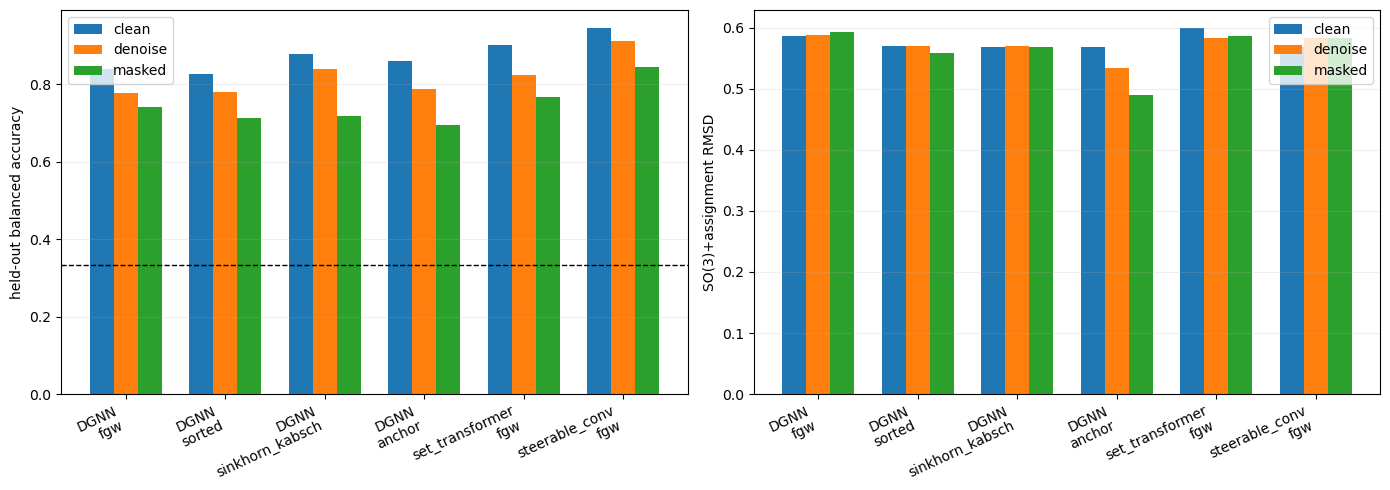

In [15]:
if RUN_MAIN_BENCHMARK:
    metric_columns = [
        "test_FGW_geometry", "test_SO3_assignment_RMSD", "test_pair_distance_MAE",
        "probe_balanced_accuracy", "probe_macro_F1", "runtime_seconds",
    ]
    display(results.pivot_table(index=["experiment", "training_loss"], columns="regime", values=metric_columns).round(4))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    names = list(dict.fromkeys(results["experiment"]))
    width = 0.24
    x = np.arange(len(names))
    for offset, regime in enumerate(REGIMES):
        subset = results.set_index(["experiment", "regime"])
        probe_values = [subset.loc[(name, regime), "probe_balanced_accuracy"] for name in names]
        rmsd_values = [subset.loc[(name, regime), "test_SO3_assignment_RMSD"] for name in names]
        axes[0].bar(x + (offset - 1) * width, probe_values, width, label=regime)
        axes[1].bar(x + (offset - 1) * width, rmsd_values, width, label=regime)
    axes[0].axhline(1/3, color="black", linestyle="--", linewidth=1)
    axes[0].set_ylabel("held-out balanced accuracy")
    axes[1].set_ylabel("SO(3)+assignment RMSD")
    for ax in axes:
        ax.set_xticks(x, [name.replace("distance_gnn__", "DGNN\n").replace("__", "\n") for name in names], rotation=25, ha="right")
        ax.grid(axis="y", alpha=0.2)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 7. Latent plots, invariance audit, and thermal-noise stability

The invariance audit transforms clean graphs without applying the training corruption. It reports maximum differences in the global latent and canonical decoder output. Both should remain near numerical tolerance.

Noise stability compares clean and noisy latents using cosine similarity and relative $L_2$ change. This is reported for every trained model, not only the denoising regime.


In [16]:
def invariant_model_audit(artifact, dataset):
    model = artifact["model"].to(DEVICE).eval()
    x = torch.from_numpy(dataset["coordinates"][:8]).to(DEVICE)
    observed = torch.ones(len(x), N_NODES, 1, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 700)
    transformed = permute_neighbors(x, generator)
    rotations = random_rotation_matrices(len(x), DEVICE, generator)
    transformed = transformed @ rotations.transpose(-1, -2)
    with torch.no_grad():
        output, latent = model(x, observed)
        transformed_output, transformed_latent = model(transformed, observed)
    model.cpu()
    return {
        "experiment": artifact["spec"]["name"],
        "regime": artifact["regime"],
        "latent_max_abs_difference": (latent - transformed_latent).abs().max().item(),
        "decoder_max_abs_difference": (output - transformed_output).abs().max().item(),
    }


def noise_stability(artifact, dataset):
    model = artifact["model"].to(DEVICE).eval()
    clean = torch.from_numpy(dataset["coordinates"][:EVAL_MAX_SAMPLES]).to(DEVICE)
    observed = torch.ones(len(clean), N_NODES, 1, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 800)
    with torch.no_grad():
        reference = model.encoder(clean, observed)
        rows = []
        for sigma in NOISE_LEVELS:
            noisy = clean.clone()
            noise = torch.randn(noisy.shape, device=DEVICE, generator=generator)
            noisy[:, 1:] += sigma * noise[:, 1:]
            latent = model.encoder(noisy, observed)
            rows.append({
                "experiment": artifact["spec"]["name"], "regime": artifact["regime"],
                "noise_sigma": sigma,
                "latent_cosine_similarity": F.cosine_similarity(reference, latent, dim=-1).mean().item(),
                "latent_relative_L2": ((latent - reference).norm(dim=-1) / reference.norm(dim=-1).clamp_min(1e-8)).mean().item(),
            })
    model.cpu()
    return rows


invariance_table = pd.DataFrame()
noise_table = pd.DataFrame()
if RUN_MAIN_BENCHMARK:
    invariance_table = pd.DataFrame([invariant_model_audit(a, dataset) for a in artifacts.values()])
    noise_table = pd.DataFrame([
        row for artifact in artifacts.values() for row in noise_stability(artifact, dataset)
    ])
    display(invariance_table.sort_values(["experiment", "regime"]).style.format({
        "latent_max_abs_difference": "{:.3e}", "decoder_max_abs_difference": "{:.3e}"
    }))
    display(noise_table.groupby(["experiment", "regime", "noise_sigma"]).mean().round(5))


,experiment,regime,latent_max_abs_difference,decoder_max_abs_difference
9,distance_gnn__anchor,clean,1.788e-07,2.384e-07
10,distance_gnn__anchor,denoise,2.384e-07,3.576e-07
11,distance_gnn__anchor,masked,2.384e-07,2.384e-07
0,distance_gnn__fgw,clean,3.576e-07,2.384e-07
1,distance_gnn__fgw,denoise,2.384e-07,2.682e-07
2,distance_gnn__fgw,masked,3.576e-07,2.384e-07
6,distance_gnn__sinkhorn_kabsch,clean,3.576e-07,2.384e-07
7,distance_gnn__sinkhorn_kabsch,denoise,2.384e-07,2.384e-07
8,distance_gnn__sinkhorn_kabsch,masked,2.384e-07,2.384e-07
3,distance_gnn__sorted,clean,2.384e-07,2.384e-07


latent_cosine_similarity  \
experiment           regime  noise_sigma                             
distance_gnn__anchor clean   0.01                          1.00000   
                             0.03                          1.00000   
                             0.05                          1.00000   
                             0.10                          1.00000   
                     denoise 0.01                          1.00000   
...                                                            ...   
steerable_conv__fgw  denoise 0.10                          0.99473   
                     masked  0.01                          0.99999   
                             0.03                          0.99996   
                             0.05                          0.99987   
                             0.10                          0.99932   

                                          latent_relative_L2  
experiment           regime  noise_sigma                      
distance_gnn__anchor clean   0.01                    0.00019  
                             0.03                    0.00056  
                             0.05                    0.00101  
                             0.10                    0.00230  
                     denoise 0.01                    0.00018  
...                                                      ...  
steerable_conv__fgw  denoise 0.10                    0.09778  
                     masked  0.01                    0.00289  
                             0.03                    0.00843  
                             0.05                    0.01451  
                             0.10                    0.03250  

[72 rows x 2 columns]

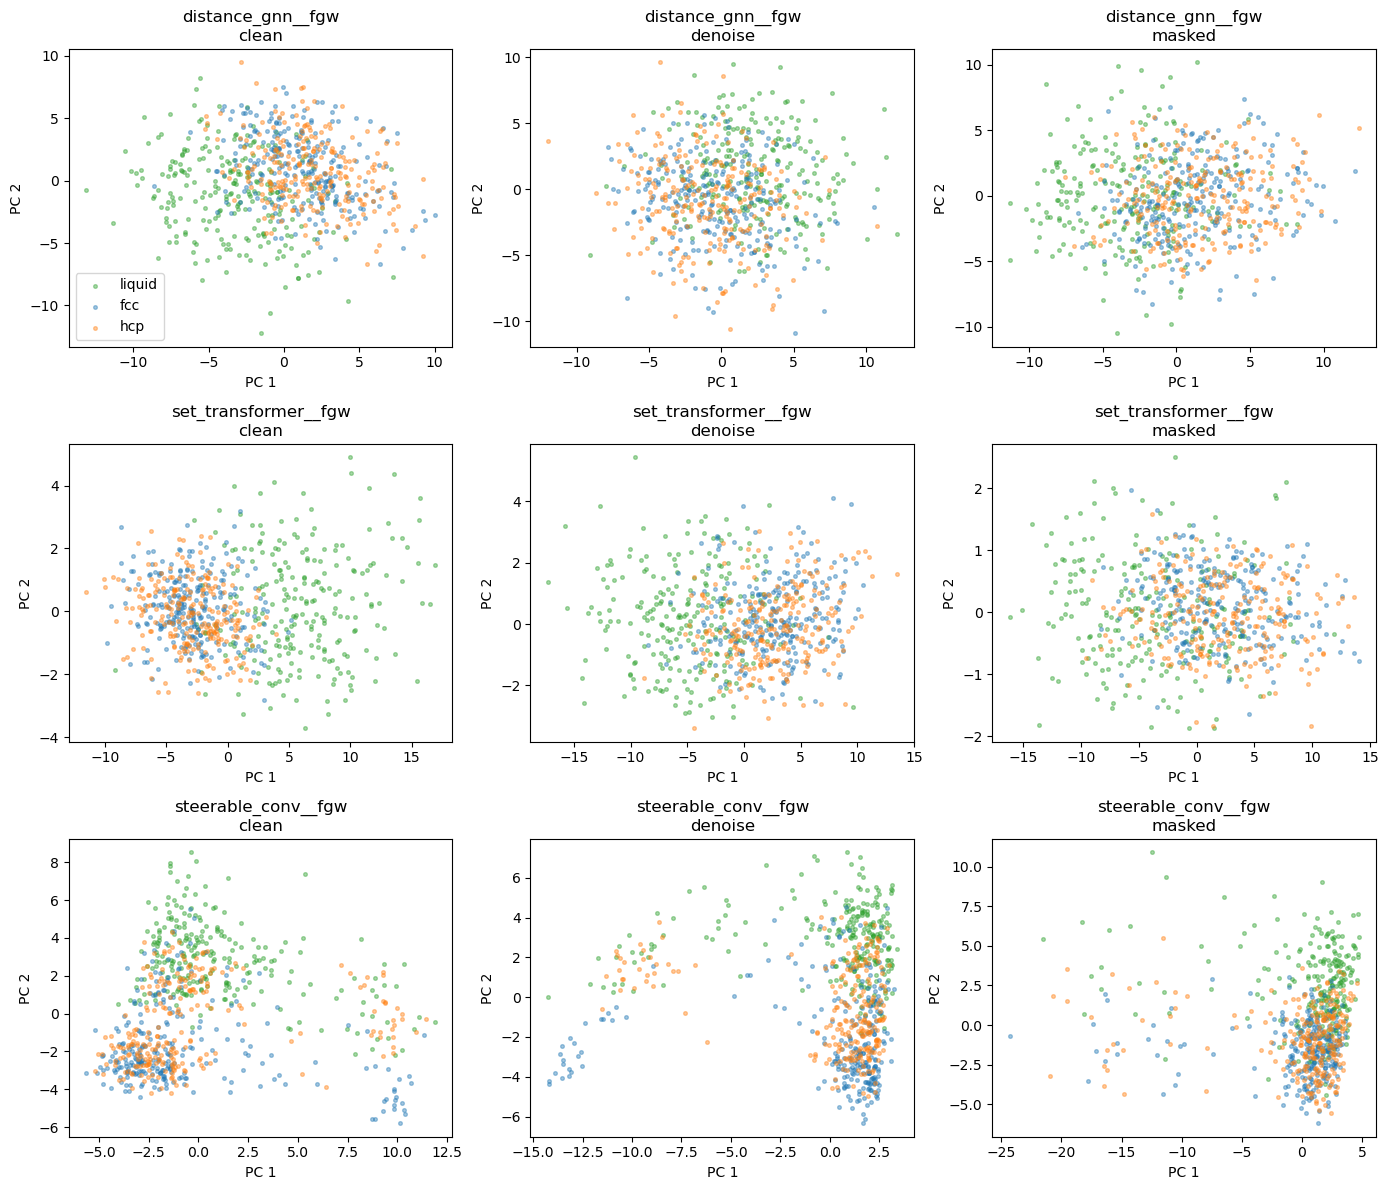

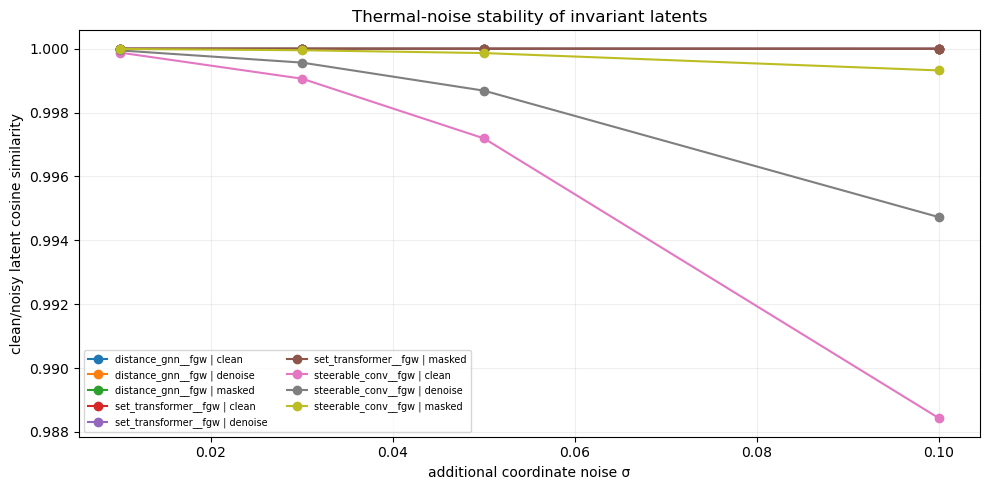

In [17]:
if RUN_MAIN_BENCHMARK:
    primary_names = ("distance_gnn__fgw", "set_transformer__fgw", "steerable_conv__fgw")
    available = [name for name in primary_names if (name, "denoise") in artifacts]
    fig, axes = plt.subplots(len(available), len(REGIMES), figsize=(14, 4 * len(available)), squeeze=False)
    test = dataset["split"] == "test"
    for row, name in enumerate(available):
        for col, regime in enumerate(REGIMES):
            embedding = derived[(name, regime)]["embedding"]
            ax = axes[row, col]
            for phase in PHASES:
                mask = test & (dataset["labels"] == LABEL_MAP[phase])
                ax.scatter(embedding[mask, 0], embedding[mask, 1], s=7, alpha=0.4,
                           color=LABEL_COLORS[phase], label=phase)
            ax.set_title(f"{name}\n{regime}")
            ax.set_xlabel("PC 1")
            ax.set_ylabel("PC 2")
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for (experiment, regime), group in noise_table.groupby(["experiment", "regime"]):
        if experiment in available:
            ax.plot(group["noise_sigma"], group["latent_cosine_similarity"], marker="o",
                    label=f"{experiment} | {regime}")
    ax.set(xlabel="additional coordinate noise σ", ylabel="clean/noisy latent cosine similarity",
           title="Thermal-noise stability of invariant latents")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


## 8. Five-seed robustness and latent-width hooks

The main matrix contains 18 fits. Repeating all of it over five seeds requires 90 fits, so robustness is implemented but opt-in. The aggregation reports mean, standard deviation, minimum, and maximum for representation and reconstruction metrics.

The width hook repeats the three primary FGW encoders over latent dimensions 16, 32, and 64. Run it only after choosing a promising training regime; changing the global `LATENT_DIM` requires rerunning the model-definition cells.


In [18]:
if RUN_FIVE_SEED_ROBUSTNESS:
    robustness_frames = [results]
    for seed in ROBUSTNESS_SEEDS:
        if seed == MAIN_SEED:
            continue
        seeded_dataset = prepare_dataset(seed)
        seeded_artifacts = run_experiment_matrix(seeded_dataset, seed, keep_artifacts=True)
        seeded_rows = [evaluate_artifact(a, seeded_dataset)[0] for a in seeded_artifacts.values()]
        robustness_frames.append(pd.DataFrame(seeded_rows))
        del seeded_artifacts
        gc.collect()
    robustness_results = pd.concat(robustness_frames, ignore_index=True)
    display(
        robustness_results.groupby(["experiment", "regime"])[[
            "test_FGW_geometry", "test_SO3_assignment_RMSD", "test_pair_distance_MAE",
            "probe_balanced_accuracy", "probe_macro_F1",
        ]].agg(["mean", "std", "min", "max"]).round(4)
    )

if RUN_LATENT_WIDTH_ABLATION:
    print(
        "Set LATENT_DIM to each value in LATENT_DIMENSIONS, rerun model-definition cells, "
        "and train the E1/E3/E4 FGW rows for the selected regime. This explicit rerun avoids "
        "silently mixing model classes constructed with different global constants."
    )


## 9. Decision rules

Do not select a model from its PCA appearance. Use the following order:

1. Reject any model whose invariance audit is not near numerical tolerance.
2. Compare FGW, aligned RMSD, and pair-distance MAE within each corruption regime.
3. Prefer denoising/masking only when they improve noise stability or held-out probe quality without a large geometry penalty.
4. Compare E1, E3, and E4 under the same FGW loss to isolate the encoder.
5. Use E2 only to select the reconstruction loss; anchor instability under thermal noise is itself an important negative result.
6. Require the five-seed distribution before claiming one representation is better.

### Important limitations

- A canonical set decoder does not preserve particle identities; that is intentional for identical particles.
- FGW is entropically regularized and approximate. Sinkhorn temperature and iteration-count sensitivity should be checked for the winning model.
- Distance-only objectives identify generic point clouds up to rigid motion and reflection, but homometric exceptions exist.
- The E4 invariant contraction uses learned equivariant features, not handcrafted order parameters, but it still encodes a symmetry prior through irreducible representations.
- Masking coordinates by zero is safe only because an explicit observed-mask feature is supplied.
